# The labels PPO could not reach, and the four levers that reached them

`02` converged at held-out exact match 0.285 on test. Two things held it there, and neither was the
critic: **a label the policy never said** (`colloidal_fouling`, 0 of 29, all answered `scaling`), and
**the severe action**, `isolate_and_evaluate_replacement`, said right 11 times in 64. A policy
gradient reweights what the policy samples; a label that is never sampled cannot be learned
(`smoke_test/10`). This notebook finds what kept labels out of reach on this 0.8B model and moves
them back in, one setting per run, prompt v2 unchanged.

**Three runs converged, each one change from the last** (every run starts from a seed, not from the
run before it). Held out, greedy, on the 200 test cases:

| run | starts from | differs from the row above in | exact match | cause | action |
| --- | --- | --- | --- | --- | --- |
| `kl001-s0` (02) | 02's tool seed | -- | 0.285 | 0.825 | 0.605 |
| `eps1e6-s0` | the **stage seed** | the seed; answer scaffolding frozen; Adam eps 1e-6 | 0.380 | 0.850 | 0.685 |
| `pc4-eps-s0` | the **label seed** (4 records per cause) | the seed | 0.805 | 0.990 | 0.810 |
| `pc4-severe3-s0` | the same label seed | a correct severe action pays **3x** | **0.985** | **0.995** | **0.995** |

On holdout_shift the last run scores exact match 0.940 (02: 0.400), on train 0.990: no gap between the
cases it trained on and the ones it never saw. Every run stopped itself by converging; none was stopped
by a gate.

In [1]:
import collections, importlib.util, json, math, re, statistics as st, sys, warnings
from pathlib import Path

HERE = Path.cwd() if (Path.cwd() / "03_label_levers.py").exists() else Path("experiments/notebooks/smoke_test35")
# This notebook's own module; the file name starts with a digit, so it is loaded by path.
spec = importlib.util.spec_from_file_location("lev03", HERE / "03_label_levers.py")
lev03 = importlib.util.module_from_spec(spec)
sys.modules["lev03"] = lev03
spec.loader.exec_module(lev03)
from reward import parse_answer
warnings.filterwarnings("ignore")

RUNS, RUNS02 = lev03.RUNS, HERE / "02_tool_seed_ppo_runs"
splits = {s: {c["id"]: c for c in lev03.load_cases(s)} for s in ("train", "dev", "test", "holdout_shift")}
SEVERE = lev03.SEVERE_ACTION
CAUSES = ("scaling", "oxidation_damage", "organic_fouling", "colloidal_fouling", "biofouling", "compaction",
          "mechanical_leak")

def episodes(path):
    return [json.loads(l) for l in Path(path).read_text().splitlines() if l.strip()]

def field(key, text):
    m = re.search(rf'"{key}"\s*:\s*"([^"]*)"', text)
    return m.group(1) if m else None

def overall(path):
    return json.loads(Path(path).read_text())["overall"]

print(lev03.MODEL, "| prompt", lev03.PROMPT_VERSION, "| splits", {s: len(c) for s, c in splits.items()})

Qwen/Qwen3.5-0.8B | prompt v2 | splits {'train': 400, 'dev': 200, 'test': 200, 'holdout_shift': 50}


## Where 02 stopped: the stage slot

The answer writes `stage` (`lead` or `tail`, a value the prompt states) just before `root_cause`.
**02's seed writes a root cause there instead on 164 of 200 dev answers.** Nothing in its training
touched that slot -- the seed learned the calls and the answer's `{` -- so the slot is whatever the raw
model writes, and the raw model writes a diagnosis.

PPO has to undo that in its first steps, and it does not always. From that seed, one run fixed the
stage by step 30 (`kl001-s0`); another, one setting apart, kept the root cause in the slot for 470
steps. That run's root cause had come to **copy the stage slot**: re-decoding its answers with the
true stage written in dropped its cause accuracy from 0.910 to 0.580 (oxidation 28 -> 6 of 28,
mechanical leak 25 -> 0). Writing the right stage would cost it the cause, so a policy gradient that
moves one token at a time cannot leave. It lost the stage's 0.03 and the schema's 0.10 on most answers
and held exact match near 0.05.

**The stage seed** is 02's seed with the stage value labelled too -- a copy of a value in the prompt,
no diagnosis. Everything else in the seed is the same, and so is everything it scores except the stage.

In [2]:
def stage_right(path, split="dev"):
    rows = episodes(path)
    return sum(field("stage", r["text"]) == splits[split][r["id"]]["answer"]["stage"] for r in rows), len(rows)

OLD_SEED = RUNS02 / "tool-seed-anchor"
STAGE_SEED = RUNS / "tool-seed-stage"
print(f"  {'':12} {'stage right':>12} {'reward':>7} {'exact':>6} {'schema':>7} {'flags':>6} {'numeric':>8} {'cause':>6}")
for name, path in (("02's seed", OLD_SEED / "epoch3-stopjson-dev.json"), ("stage seed", STAGE_SEED / "epoch3-dev.json")):
    o = overall(path)
    right, n = stage_right(path.with_suffix(".episodes.jsonl"))
    print(f"  {name:12} {f'{right}/{n}':>12} {o['reward']:7.3f} {o['exact_match']:6.3f} {o['schema_ok']:7.3f} "
          f"{o['flags_acc']:6.3f} {o['numeric_acc']:8.3f} {o['cause_acc']:6.3f}")

# What the stage seed labels: the calls, their <|im_end|>, the answer's `{`, the stage value.
from transformers import AutoTokenizer
tok = AutoTokenizer.from_pretrained(lev03.MODEL)
case = next(iter(splits["train"].values()))
ids, labels = lev03.label_seed_example(case, tok, ("stage",))
lab = [t for t, l in zip(ids[0].tolist(), labels[0].tolist()) if l != -100]
tail = tok.decode(lab[-3:])
print(f"\n  labelled tokens per example: {len(lab)}; the last three decode to {tail!r} "
      f"(the calls' `</tool_call><|im_end|>`, then `{{` and the stage `{case['answer']['stage']}`)")
print("  stage seed config:", json.loads((STAGE_SEED / "config.json").read_text())["loss"])

                stage right  reward  exact  schema  flags  numeric  cause
  02's seed          36/200   0.540  0.025   0.105  0.610    1.000  0.285
  stage seed        200/200   0.637  0.105   1.000  0.605    1.000  0.225



  labelled tokens per example: 264; the last three decode to '<|im_end|>{tail' (the calls' `</tool_call><|im_end|>`, then `{` and the stage `tail`)
  stage seed config: the three gold calls and <|im_end|>, and the answer turn's first token, the stage value


## The settings, and where each came from

The runs are `kl001-s0`'s configuration (02) plus the settings below, each added after a measured
failure on this model and each aimed at that one failure. All of them change what is trained or how;
none changes the prompt, the reward, or what any evaluation scores.

| setting | what it does | measured when it was missing |
| --- | --- | --- |
| **stage seed** (`seed --slots stage`) | the seed also labels the stage value | 02's seed wrote a cause into `stage` on 164/200 dev answers; one run locked in (above) |
| **answer scaffolding frozen** (`freeze_answer_structure`) | in the answer turn the actor's loss covers only the tokens that spell a value -- the numbers, the flags, stage, cause, action; keys, quotes, braces and whitespace keep the seed's probabilities | from the stage seed, values came out unquoted (`"root_cause": mechanical_leak`) 7 actor steps in; the arithmetic gate stopped the run at step 32 |
| **Adam eps 1e-6** (`adam_eps`) | Adam's epsilon at the median of the running root squared gradient, so a parameter whose gradient is tiny but steady no longer takes a full-size step | with the scaffolding frozen it still moved -- numbers written as strings, the `action` key dropped -- and the run stopped at step 51. At that point the root second moment across the 5.5M LoRA parameters spanned 4.7e-8 (10%) to 7.5e-6 (90%), median 8.4e-7, and the default epsilon (1e-8) damped none of it |
| **label seed, 4 records per cause** (`labelseed --per-cause 4 --replay-slots stage`) | the stage seed plus 28 off-distribution records, labelled on the stage, cause and action values only | from the stage seed PPO never said `scaling` (0 of 29 on test): the seed said it 2 times in 400 samples |
| **severe x3** (`severe_credit_scale 3`) | a correct `isolate_and_evaluate_replacement` pays the action's 0.15 three times, in training only | from the label seed, PPO stopped saying the severe action (0 of 37 on test): the seed said it 21 times in 400 samples, right 4 times -- `smoke_test/14`'s precision problem |

The label records are `smoke_test/11`'s `seed_cases.jsonl`, generated outside every band the task's
splits occupy. They share no record and no id with any split:

In [3]:
seed_cases = episodes(HERE.parent / "smoke_test" / "data" / "seed_cases.jsonl")
key = lambda c: json.dumps(c["record"], sort_keys=True)  # noqa: E731
seed_keys, seed_ids = {key(c) for c in seed_cases}, {c["id"] for c in seed_cases}
for s, cs in splits.items():
    print(f"  {s:>13}: {sum(key(c) in seed_keys for c in cs.values())} shared records, {len(seed_ids & set(cs))} shared ids")
cfg = json.loads((RUNS / "label-seed-pc4" / "config.json").read_text())
print(f"\n  label-seed-pc4: {len(cfg['label_case_ids'])} records, {cfg['label_cause_counts']}")
print(f"  labelled on the label records: stage + {cfg['slots']}; on the 400 train replays: {cfg['replay_slots']}")

          train: 0 shared records, 0 shared ids
            dev: 0 shared records, 0 shared ids
           test: 0 shared records, 0 shared ids
  holdout_shift: 0 shared records, 0 shared ids

  label-seed-pc4: 28 records, {'scaling': 4, 'oxidation_damage': 4, 'organic_fouling': 4, 'colloidal_fouling': 4, 'biofouling': 4, 'compaction': 4, 'mechanical_leak': 4}
  labelled on the label records: stage + ['root_cause', 'action']; on the 400 train replays: ['stage']


## How much label seed

The label seed is meant to make every cause *sampled* -- visible to the policy gradient -- without
teaching the table. Below, each seed's answers at temperature 1 on all of dev (2 samples a case):
for each true cause, the times the seed said it right, over the times it said it at all.

**No dose makes all seven barely visible; the labels compete.** Two records per cause revive
`scaling` but nearly silence `compaction` and `mechanical_leak` and loosen the format (schema 0.735).
Eight per cause is close to supervised learning (cause 0.495 before any PPO) and pushes three causes
down to 4-11 mentions. **Four per cause is the weakest dose at which every cause is said at least 8
times**; it over-says `colloidal_fouling` (114 times, 36 right), which PPO can correct because it
samples it.

  none (stage seed): schema 0.965 cause 0.205 |   scaling  1/2    oxidation  5/61   organic_f  1/3    colloidal  4/14   biofoulin 57/218  compactio 18/83   mechanica  1/10 
        2 per cause: schema 0.735 cause 0.230 |   scaling  9/55   oxidation 18/53   organic_f  5/18   colloidal 13/33   biofoulin 49/205  compactio  1/6    mechanica  0/5  
        4 per cause: schema 0.915 cause 0.290 |   scaling  9/12   oxidation 10/37   organic_f  8/15   colloidal 36/114  biofoulin 52/165  compactio  4/32   mechanica  3/8  
        8 per cause: schema 0.955 cause 0.495 |   scaling 57/111  oxidation  9/11   organic_f 26/64   colloidal 47/78   biofoulin 55/116  compactio  2/4    mechanica  2/4  


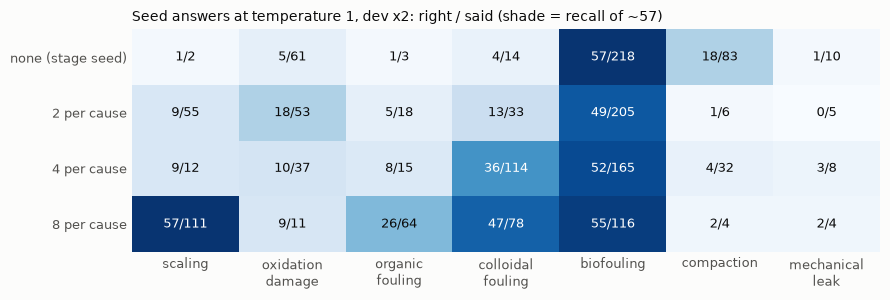

In [4]:
import matplotlib.pyplot as plt
import numpy as np

SURFACE, INK, INK2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e7e6e2"
plt.rcParams.update({"figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "axes.edgecolor": GRID,
                     "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2, "text.color": INK,
                     "font.size": 10, "axes.spines.top": False, "axes.spines.right": False})

DOSES = [("none (stage seed)", RUNS / "tool-seed-stage"), ("2 per cause", RUNS / "label-seed-pc2"),
         ("4 per cause", RUNS / "label-seed-pc4"), ("8 per cause", RUNS / "label-seed-pc8")]
right = np.zeros((len(DOSES), len(CAUSES)))
said = np.zeros_like(right)
true_n = collections.Counter()
for i, (name, d) in enumerate(DOSES):
    rows = episodes(d / "epoch3-probe-T1.episodes.jsonl")
    for r in rows:
        truth, c = splits["dev"][r["id"]]["answer"]["root_cause"], field("root_cause", r["text"])
        if i == 0:
            true_n[truth] += 1
        if c in CAUSES:
            said[i, CAUSES.index(c)] += 1
            right[i, CAUSES.index(c)] += c == truth
    o = overall(d / "epoch3-probe-T1.json")
    cells = "  ".join(f"{c[:9]:>9} {int(right[i, j]):>2}/{int(said[i, j]):<3}" for j, c in enumerate(CAUSES))
    print(f"  {name:>17}: schema {o['schema_ok']:.3f} cause {o['cause_acc']:.3f} | {cells}")

recall = right / np.array([true_n[c] for c in CAUSES])
fig, ax = plt.subplots(figsize=(9, 3.1))
ax.imshow(recall, cmap="Blues", vmin=0, vmax=1, aspect="auto")
for i in range(len(DOSES)):
    for j in range(len(CAUSES)):
        ax.text(j, i, f"{int(right[i, j])}/{int(said[i, j])}", ha="center", va="center", fontsize=9,
                color="white" if recall[i, j] > 0.55 else INK)
ax.set_xticks(range(len(CAUSES)), [c.replace("_", "\n") for c in CAUSES], fontsize=9)
ax.set_yticks(range(len(DOSES)), [n for n, _ in DOSES], fontsize=9)
ax.tick_params(length=0)
for s in ax.spines.values():
    s.set_visible(False)
ax.set_title("Seed answers at temperature 1, dev x2: right / said (shade = recall of ~57)", loc="left", fontsize=10)
fig.tight_layout()
fig.savefig(HERE / "03_label_levers_dose.png", dpi=150)
plt.show()

In [5]:
RUN_NAMES = ("eps1e6-s0", "pc4-eps-s0", "pc4-severe3-s0")
base = json.loads((RUNS02 / "kl001-s0" / "config.json").read_text())
for name in RUN_NAMES:
    cfg = json.loads((RUNS / name / "config.json").read_text())
    # settings kl001-s0 predates count at their no-op value
    noop = {"severe_credit_scale": 1.0, "colloidal_credit_scale": 1.0, "freeze_answer_structure": 0, "adam_eps": 1e-8}
    diff = {k: v for k, v in cfg.items() if base.get(k, noop.get(k)) != v and k != "keep_eval_checkpoints"}
    end = json.loads((RUNS / name / "ending.json").read_text())
    print(f"{name}: differs from kl001-s0 in {diff}")
    print(f"    ended at step {end['stopped_at']}: {end['reason']}\n")

eps1e6-s0: differs from kl001-s0 in {'start_from': '03_label_levers_runs/tool-seed-stage/epoch3', 'freeze_answer_structure': 1, 'adam_eps': 1e-06}
    ended at step 900: converged: 8 evaluations without beating held-out reward 0.9083 (step 700)

pc4-eps-s0: differs from kl001-s0 in {'start_from': '03_label_levers_runs/label-seed-pc4/epoch3', 'freeze_answer_structure': 1, 'adam_eps': 1e-06}
    ended at step 450: converged: 8 evaluations without beating held-out reward 0.9717 (step 250)

pc4-severe3-s0: differs from kl001-s0 in {'start_from': '03_label_levers_runs/label-seed-pc4/epoch3', 'severe_credit_scale': 3.0, 'freeze_answer_structure': 1, 'adam_eps': 1e-06}
    ended at step 525: converged: 8 evaluations without beating held-out reward 0.9992 (step 325)



## The runs

Held out on the 200 dev cases every 25 steps, greedy. Each run stopped itself after eight evaluations
without beating its best held-out reward; none was stopped by a gate. The dashed line is the
checkpoint each run keeps.

From the stage seed with the scaffolding frozen and Adam's epsilon raised, the answer's format held
for 900 steps (schema at least 0.985 at every evaluation) and the run passed `kl001-s0` -- but it never
said `scaling`. Started instead from the label seed, the same configuration reached in 75 steps what the
first had reached in 900, and went on to cause 0.99-1.00. With the severe action paid 3x, action
accuracy first dipped while the policy said it on the wrong cases (0.79 -> 0.72 at step 100) and then
jumped to 0.98 at step 125.

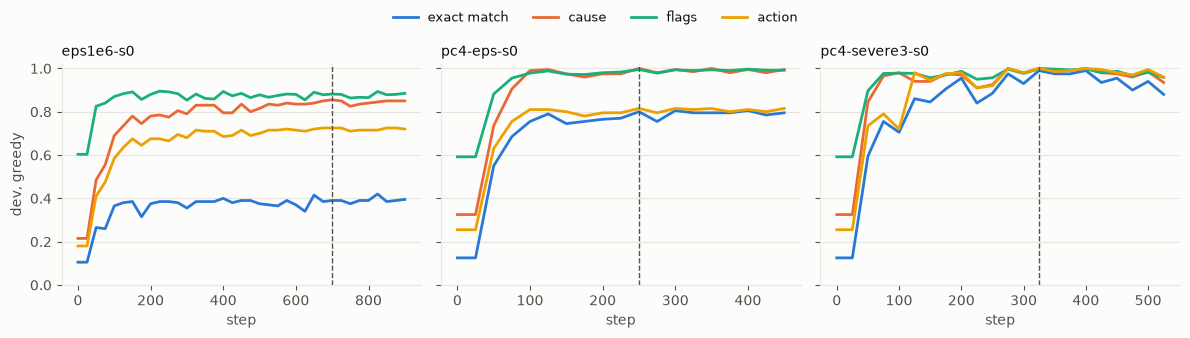

  eps1e6-s0       best step  700: reward 0.9083 exact 0.390 cause 0.855 flags 0.882 action 0.725 schema 1.000
  pc4-eps-s0      best step  250: reward 0.9717 exact 0.800 cause 1.000 flags 0.995 action 0.815 schema 1.000
  pc4-severe3-s0  best step  325: reward 0.9992 exact 0.990 cause 1.000 flags 0.998 action 1.000 schema 1.000


In [6]:
SERIES = {"exact_match": ("exact match", "#2a78d6"), "cause_acc": ("cause", "#eb6834"),
          "flags_acc": ("flags", "#1baf7a"), "action_acc": ("action", "#eda100")}
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), sharey=True)
for ax, name in zip(axes, RUN_NAMES):
    evals = [json.loads(l) for l in (RUNS / name / "eval.jsonl").read_text().splitlines()]
    best = json.loads((RUNS / name / "best.json").read_text())["step"]
    steps = [e["step"] for e in evals]
    for k, (label, color) in SERIES.items():
        ax.plot(steps, [e[k] for e in evals], color=color, lw=2, label=label)
    ax.axvline(best, color=INK2, lw=1, ls="--")
    ax.set_title(name, loc="left", fontsize=10)
    ax.set_xlabel("step")
    ax.grid(axis="y", color=GRID, lw=0.8)
    ax.set_ylim(0, 1.02)
axes[0].set_ylabel("dev, greedy")
fig.legend(*axes[0].get_legend_handles_labels(), frameon=False, loc="upper center", ncol=4, fontsize=9)
fig.tight_layout(rect=(0, 0, 1, 0.92))
fig.savefig(HERE / "03_label_levers_curves.png", dpi=150)
plt.show()
for name in RUN_NAMES:
    best = json.loads((RUNS / name / "best.json").read_text())
    print(f"  {name:15} best step {best['step']:>4}: reward {best['reward']:.4f} exact {best['exact_match']:.3f} "
          f"cause {best['cause_acc']:.3f} flags {best['flags_acc']:.3f} action {best['action_acc']:.3f} schema {best['schema_ok']:.3f}")

## The critic

The critic's explained variance minus the position-only clock's, median over each 25-step window. In
every run it is behind during the warm-up (-0.04 to -0.05), level in the window after it (-0.005 to
+0.002), ahead from the 50-74 window, and ahead by at least +0.02 from step 75 to the end (up to
+0.044) -- the margin `kl001-s0` and the 1.7B series reached. The critic gate (two evaluations behind
the clock stop a run) never fired.

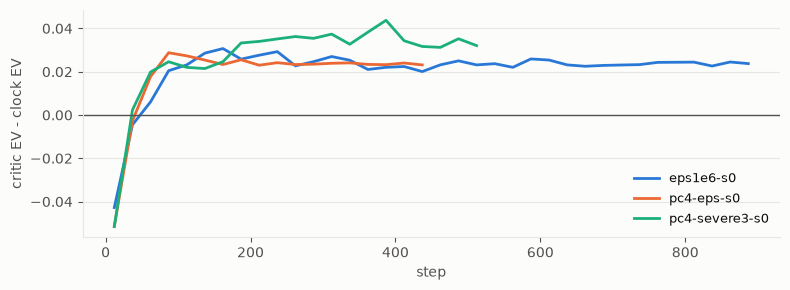

In [7]:
fig, ax = plt.subplots(figsize=(8, 3))
for name, color in zip(RUN_NAMES, ("#2a78d6", "#eb6834", "#1baf7a")):
    rows = [json.loads(l) for l in (RUNS / name / "metrics.jsonl").read_text().splitlines()]
    xs, ys = [], []
    for a in range(0, len(rows) - 24, 25):
        vals = [r["value_ev"] - r["value_ev_position"] for r in rows[a:a + 25]
                if r["value_ev"] is not None and r["value_ev_position"] is not None]
        if vals:
            xs.append(a + 12); ys.append(st.median(vals))
    ax.plot(xs, ys, color=color, lw=2, label=name)
ax.axhline(0, color=INK2, lw=1)
ax.set_xlabel("step"); ax.set_ylabel("critic EV - clock EV")
ax.grid(axis="y", color=GRID, lw=0.8)
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(HERE / "03_label_levers_critic.png", dpi=150)
plt.show()

## Held out

Each run's kept checkpoint and the seeds they started from, greedy, on every split. Dev chose the
checkpoints; test, holdout_shift and train chose nothing. The paired tests compare two policies on the
same cases (McNemar, exact binomial): the first count is cases only the later run gets right, the
second those only the earlier one does.

In [8]:
ROWS = [("02 seed", RUNS02 / "tool-seed-anchor", "epoch3-stopjson-"), ("kl001-s0 (02)", RUNS02 / "kl001-s0", "best-"),
        ("stage seed", RUNS / "tool-seed-stage", "epoch3-"), ("eps1e6-s0", RUNS / "eps1e6-s0", "best-"),
        ("label seed pc4", RUNS / "label-seed-pc4", "epoch3-"), ("pc4-eps-s0", RUNS / "pc4-eps-s0", "best-"),
        ("pc4-severe3-s0", RUNS / "pc4-severe3-s0", "best-")]
print(f"  {'':15} {'split':>13} {'reward':>7} {'exact':>6} {'cause':>6} {'flags':>6} {'action':>7} {'numeric':>8} {'schema':>7}")
for split in ("test", "holdout_shift", "train", "dev"):
    for name, d, pre in ROWS:
        p = d / f"{pre}{split}.json"
        if not p.exists():
            continue
        o = overall(p)
        print(f"  {name:15} {split:>13} {o['reward']:7.3f} {o['exact_match']:6.3f} {o['cause_acc']:6.3f} "
              f"{o['flags_acc']:6.3f} {o['action_acc']:7.3f} {o['numeric_acc']:8.3f} {o['schema_ok']:7.3f}")
    print()

def per_case(path, split):
    out = {}
    for r in episodes(path):
        a = splits[split][r["id"]]["answer"]
        p = parse_answer(r["text"])
        o = p.obj if isinstance(p.obj, dict) else {}
        cause, action = o.get("root_cause") == a["root_cause"], o.get("action") == a["action"]
        out[r["id"]] = (cause and action and o.get("stage") == a["stage"] and o.get("flags") == a["flags"], cause, action)
    return out

def mcnemar(b, c):
    n, k = b + c, min(b, c)
    return min(1.0, 2 * sum(math.comb(n, i) for i in range(k + 1)) / 2 ** n) if n else 1.0

PAIRS = [("eps1e6-s0", RUNS / "eps1e6-s0", "kl001-s0", RUNS02 / "kl001-s0"),
         ("pc4-eps-s0", RUNS / "pc4-eps-s0", "eps1e6-s0", RUNS / "eps1e6-s0"),
         ("pc4-severe3-s0", RUNS / "pc4-severe3-s0", "pc4-eps-s0", RUNS / "pc4-eps-s0"),
         ("pc4-severe3-s0", RUNS / "pc4-severe3-s0", "kl001-s0", RUNS02 / "kl001-s0")]
for split in ("test", "holdout_shift"):
    for new, dn, old, do in PAIRS:
        A, B = per_case(dn / f"best-{split}.episodes.jsonl", split), per_case(do / f"best-{split}.episodes.jsonl", split)
        parts = []
        for i, what in enumerate(("exact*", "cause", "action")):
            b = sum(A[k][i] and not B[k][i] for k in A)
            c = sum(B[k][i] and not A[k][i] for k in A)
            parts.append(f"{what} {b:>3} vs {c:<3} p={mcnemar(b, c):.1g}")
        print(f"  {split:>13} {new} vs {old}: " + " | ".join(parts))
print("\n  * exact here compares flags, stage, cause and action; on test and holdout_shift every run has every number right")

                          split  reward  exact  cause  flags  action  numeric  schema
  02 seed                  test   0.531  0.005  0.290  0.598   0.140    1.000   0.095
  kl001-s0 (02)            test   0.885  0.285  0.825  0.902   0.605    1.000   1.000
  stage seed               test   0.629  0.065  0.215  0.597   0.160    1.000   1.000
  eps1e6-s0                test   0.902  0.380  0.850  0.888   0.685    1.000   1.000
  label seed pc4           test   0.671  0.080  0.340  0.582   0.240    1.000   1.000
  pc4-eps-s0               test   0.968  0.805  0.990  0.993   0.810    1.000   1.000
  pc4-severe3-s0           test   0.997  0.985  0.995  0.995   0.995    1.000   1.000

  02 seed         holdout_shift   0.565  0.020  0.320  0.620   0.260    1.000   0.160
  kl001-s0 (02)   holdout_shift   0.900  0.400  0.820  0.913   0.700    1.000   1.000
  stage seed      holdout_shift   0.664  0.100  0.280  0.627   0.260    1.000   1.000
  eps1e6-s0       holdout_shift   0.894  0.420  0.820

## Which labels each policy could reach

Recall on test for each true cause, and for the severe action. **The dead label moved, then
disappeared.** `kl001-s0` never said `colloidal_fouling` and answered all 29 `scaling`; from the stage
seed the mirror image -- colloidal fouling 29 of 29, `scaling` never said; from the label seed every
cause at 27-29 of 29, and the one remaining gap was the severe action, 0 of 37. Paid 3x, it is
learned.

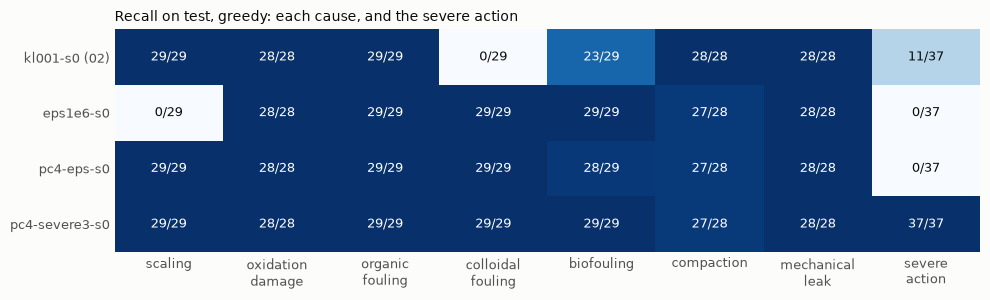

In [9]:
cols = list(CAUSES) + ["severe action"]
RECALL_RUNS = [("kl001-s0 (02)", RUNS02 / "kl001-s0"), ("eps1e6-s0", RUNS / "eps1e6-s0"),
               ("pc4-eps-s0", RUNS / "pc4-eps-s0"), ("pc4-severe3-s0", RUNS / "pc4-severe3-s0")]
hit = np.zeros((len(RECALL_RUNS), len(cols)))
tot = np.zeros_like(hit)
for i, (name, d) in enumerate(RECALL_RUNS):
    for r in episodes(d / "best-test.episodes.jsonl"):
        a = splits["test"][r["id"]]["answer"]
        j = CAUSES.index(a["root_cause"])
        tot[i, j] += 1
        hit[i, j] += field("root_cause", r["text"]) == a["root_cause"]
        if a["action"] == SEVERE:
            tot[i, -1] += 1
            hit[i, -1] += field("action", r["text"]) == SEVERE
fig, ax = plt.subplots(figsize=(10, 3.1))
ax.imshow(hit / tot, cmap="Blues", vmin=0, vmax=1, aspect="auto")
for i in range(len(RECALL_RUNS)):
    for j in range(len(cols)):
        ax.text(j, i, f"{int(hit[i, j])}/{int(tot[i, j])}", ha="center", va="center", fontsize=9,
                color="white" if hit[i, j] / tot[i, j] > 0.55 else INK)
ax.set_xticks(range(len(cols)), [c.replace("_", "\n").replace(" ", "\n") for c in cols], fontsize=9)
ax.set_yticks(range(len(RECALL_RUNS)), [n for n, _ in RECALL_RUNS], fontsize=9)
ax.tick_params(length=0)
for s in ax.spines.values():
    s.set_visible(False)
ax.set_title("Recall on test, greedy: each cause, and the severe action", loc="left", fontsize=10)
fig.tight_layout()
fig.savefig(HERE / "03_label_levers_recall.png", dpi=150)
plt.show()

## Summary

* **The stage slot was a trap the seed set.** 02's seed wrote a cause where the stage goes on 164 of
  200 answers; PPO had to undo it early or lock in, with the root cause copying the slot. A seed that
  also labels the stage value -- a copy of a value the prompt states -- writes it right 200 of 200.
* **The drift had one mechanism, and the fix was Adam's epsilon.** Freezing the answer's scaffolding
  out of the loss did not stop the scaffolding moving, because the parameters are shared. The root
  second moment spans four decades across the LoRA parameters, and the default epsilon let a tiny,
  steady gradient take a full step. At the median (1e-6) the format held for every run after it,
  900 steps the longest.
* **Labels PPO cannot sample, it cannot learn, and which labels those are depends on the seed.** From
  02's seed `colloidal_fouling` was never said; from the stage seed, `scaling`. Four off-distribution
  records per cause, labelled on the values only, is the weakest dose at which every cause is sampled
  -- fewer silences some, more is supervised learning -- and from it PPO reaches cause 0.990 on test.
* **A label that is sampled but imprecise, PPO deletes, unless it pays enough.** The severe action,
  said 21 times and right 4 by the seed, was gone from the converged policy; paid 3x, it went to 37 of
  37 on test.
* Test exact match went 0.285 -> 0.380 -> 0.805 -> **0.985**, each step a McNemar-significant gain
  over the last (p = 0.003, 1e-23, 3e-11). What is left are flag thresholds at the boundaries --
  `up` against `sharp_up`, `flat` against `up` -- on 3 of 200 test cases and 3 of 50 holdout_shift.